# Figure 5 — PANCAN evaluation and generalization

**Panels** — (a) nested-CV mean ROC for healthy vs all seven cancer types
(PANCAN, Cristiano cohort); (b) external validation on the Jiang cohort
(hepatocellular carcinoma, unseen during training) — models trained on the
full Cristiano cohort; (c) sensitivity at 95% specificity on the Jiang
cohort; (d) within-dataset generalization — ROC on withheld BRCA/CRC
samples; (e) the same models applied to the five cancer types absent from
training; (f) sensitivity at 95% specificity for the within-dataset setting.

**Source data** (no pickles, no cluster paths, no network):
- `data/fig5a_predictions.csv` + `data/fig5a_config.csv` — per-sample
  out-of-fold predictions for the PANCAN nested CV (ichorCNA rows carry the
  tumor fraction; `n_rows_in_source` preserves the original table's
  duplicate rows).
- `data/fig5bc_external_predictions.csv` + `data/fig5bc_config.csv` —
  per-sample predictions of the deployed CRIS models on the Jiang cohort.
- `data/fig5def_roc_curves.csv` + `data/fig5def_metrics.csv` — mean ROC
  curves (with cross-split CI bands) and summary metrics of the
  within-dataset generalization experiment.

All written by `export/export_fig5.py`. Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, auc

APPROACH_COLORS = {
    "RNA": "#CA3542", "ATAC": "#ECB22E",
    "Data-driven": "#0173B2", "ichorCNA": "#6A3D9A",
}
METHOD_LABELS = {"data_driven": "Data-driven", "atac": "ATAC", "rna": "RNA",
                 "ichorcna": "ichorCNA", "dd": "Data-driven"}

pred5a = pd.read_csv("data/fig5a_predictions.csv")
cfg5a = pd.read_csv("data/fig5a_config.csv")
ext = pd.read_csv("data/fig5bc_external_predictions.csv")
ext_cfg = pd.read_csv("data/fig5bc_config.csv")
wg_curves = pd.read_csv("data/fig5def_roc_curves.csv")
wg_metrics = pd.read_csv("data/fig5def_metrics.csv")
display(cfg5a)
display(ext_cfg)

,method,feature,classifier,weighting_function,top_genes,source_dir,selection_mean_auc
0,data_driven,griffin_diff,Support Vector Machine,mean_diff,14224.0,nested_cv_results_cris/pancan_dd,0.945873
1,rna,rcov,Multi-Layer Perceptron,NaN,NaN,nested_cv_results_cris/nested_rna_pancan,0.714512
2,atac,ulz_atac_tfbs_features_pancan,Support Vector Machine,NaN,NaN,nested_cv_results_cris/pancan_atac - Copy,0.904376
3,ichorcna,ichorcna_tf,NaN,NaN,NaN,accessory_files/cris_stage_vaf_coverage_ichor.csv,NaN


,method,feature,classifier,n_genes,train_cv_auc,external_auc,threshold_95spec_external,threshold_95spec_train,proba_degenerate,source_dir
0,dd,griffin_diff,Logistic Regression,15000,0.946769,0.693992,0.778449,inf,False,nested_cv_results_cris/external_validation_com...
1,rna,rcov,Multi-Layer Perceptron,781,0.730125,0.536461,0.975607,0.616295,False,nested_cv_results_cris/external_validation_com...
2,atac,ulz_atac_tfbs_features,Support Vector Machine,497,0.916746,0.679588,0.927022,inf,True,nested_cv_results_cris/external_validation_com...


## Panel a — PANCAN nested-CV mean ROC

In [2]:
def expand(df):
    return df.loc[df.index.repeat(df["n_rows_in_source"])]


def panel_a(ax):
    base_fpr = np.linspace(0, 1, 101)
    for method in ["data_driven", "atac", "rna", "ichorcna"]:
        name = METHOD_LABELS[method]
        color = APPROACH_COLORS[name]
        df = pred5a[(pred5a["method"] == method) & pred5a["fold"].notna()]
        tprs, aucs = [], []
        for _, g in df.groupby("fold"):
            g = expand(g).dropna(subset=["score"])
            fpr, tpr, _ = roc_curve(g["y_true"], g["score"])
            tprs.append(interp1d(fpr, tpr, kind="linear")(base_fpr))
            aucs.append(auc(fpr, tpr))
        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[0], mean_tpr[-1] = 0, 1
        std_tpr = np.std(tprs, axis=0)
        ax.plot(base_fpr, mean_tpr, color=color, linewidth=2.3,
                label=f"{name} — AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")
        ax.fill_between(base_fpr, np.maximum(mean_tpr - std_tpr, 0),
                        np.minimum(mean_tpr + std_tpr, 1), color=color, alpha=0.2)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.2)
    ax.axvline(x=0.05, color="dimgray", linestyle=":", linewidth=1.6, alpha=0.85,
               zorder=1, label="95% specificity (FPR = 0.05)")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.legend(loc="lower right", fontsize=10.5, frameon=True)
    ax.tick_params(labelsize=12)

## Panels b and c — external validation (Jiang cohort)

One deployed model per method (selected on training-CV AUC before seeing the
external data). Panel c reports sensitivity at the 95%-specificity point of
the external ROC (the operating point shown in the manuscript).

In [3]:
ext_rocs = {}
for method in ["dd", "atac", "rna"]:
    g = ext[ext["method"] == method]
    fpr, tpr, thr = roc_curve(g["y_true"], g["score"])
    ext_rocs[method] = {"fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr),
                        "sens_95_ext": tpr[np.argmin(np.abs(fpr - 0.05))]}


def panel_b(ax):
    for method in ["dd", "atac", "rna"]:
        d = ext_rocs[method]
        name = METHOD_LABELS[method]
        ax.plot(d["fpr"], d["tpr"], color=APPROACH_COLORS[name], linewidth=2.3,
                label=f"{name} — AUC = {d['auc']:.3f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.2)
    ax.axvline(x=0.05, color="dimgray", linestyle=":", linewidth=1.6, alpha=0.85,
               zorder=1, label="95% specificity (FPR = 0.05)")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.legend(loc="lower right", fontsize=10.5, frameon=True, framealpha=0.9,
              edgecolor="#cccccc")
    ax.tick_params(labelsize=12)


def panel_c(ax):
    methods = ["dd", "atac", "rna"]
    x = np.arange(len(methods))
    sens = [ext_rocs[m]["sens_95_ext"] for m in methods]
    colors = [APPROACH_COLORS[METHOD_LABELS[m]] for m in methods]
    ax.bar(x, sens, color=colors, alpha=0.85, edgecolor="black", linewidth=0.6)
    for xi, (s, c) in enumerate(zip(sens, colors)):
        ax.text(xi, s + 0.02, f"{s:.2f}", ha="center", va="bottom",
                fontsize=12, fontweight="bold", color=c)
    ax.set_xticks(x)
    ax.set_xticklabels([METHOD_LABELS[m] for m in methods], fontsize=13)
    ax.set_ylabel("Sensitivity (Recall)", fontsize=15)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.tick_params(labelsize=12)

## Panels d, e and f — within-dataset generalization

Mean ROC over the five outer splits (bands: cross-split CI as stored by the
evaluation pipeline); panel f shows sensitivity at 95% specificity with the
cross-split standard deviation.

In [4]:
def panel_roc_wg(ax, subset):
    for method in ["dd", "rna", "atac"]:
        name = METHOD_LABELS[method]
        color = APPROACH_COLORS[name]
        mean = wg_curves[(wg_curves["method"] == method) & (wg_curves["subset"] == subset)
                         & (wg_curves["series"] == "mean")]
        ci = wg_curves[(wg_curves["method"] == method) & (wg_curves["subset"] == subset)
                       & (wg_curves["series"] == "ci")]
        m = wg_metrics[(wg_metrics["method"] == method) & (wg_metrics["subset"] == subset)].iloc[0]
        if len(mean) == 0:
            continue
        ax.plot(mean["fpr"], mean["tpr"], color=color, linewidth=2,
                label=f"{name} - AUC = {m['auc_mean']:.3f} ± {m['auc_std']:.3f}")
        if len(ci):
            ax.fill_between(ci["fpr"], ci["tpr_lower"], ci["tpr_upper"],
                            color=color, alpha=0.15, linewidth=0)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.2)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel("False Positive Rate", fontsize=15)
    ax.set_ylabel("True Positive Rate", fontsize=15)
    ax.legend(loc="lower right", fontsize=10.5, frameon=True, framealpha=0.9,
              edgecolor="#cccccc")
    ax.tick_params(labelsize=12)


def panel_f(ax):
    groups = ["withheld", "novel"]
    x_groups = np.arange(len(groups))
    bar_width = 0.25
    for i, method in enumerate(["dd", "rna", "atac"]):
        name = METHOD_LABELS[method]
        color = APPROACH_COLORS[name]
        rows = wg_metrics[wg_metrics["method"] == method].set_index("subset")
        means = [rows.loc[g, "sens_95"] for g in groups]
        stds = [rows.loc[g, "sens_95_std"] for g in groups]
        x_pos = x_groups + (i - 1) * bar_width
        ax.bar(x_pos, means, bar_width, yerr=stds, label=name, color=color,
               alpha=0.85, edgecolor="black", linewidth=0.5, capsize=4,
               error_kw={"linewidth": 1.2, "capthick": 1.2})
        for j, (m, s) in enumerate(zip(means, stds)):
            ax.text(x_pos[j], m + (s if s > 0 else 0) + 0.02, f"{m:.2f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold", color=color)
    ax.set_xticks(x_groups)
    ax.set_xticklabels(["Withheld", "Novel"], fontsize=13)
    ax.set_ylabel("Sensitivity (Recall)", fontsize=15)
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.legend(loc="upper left", fontsize=10, frameon=True, framealpha=0.9,
              edgecolor="#cccccc")
    ax.tick_params(labelsize=12)

## Assemble Figure 5

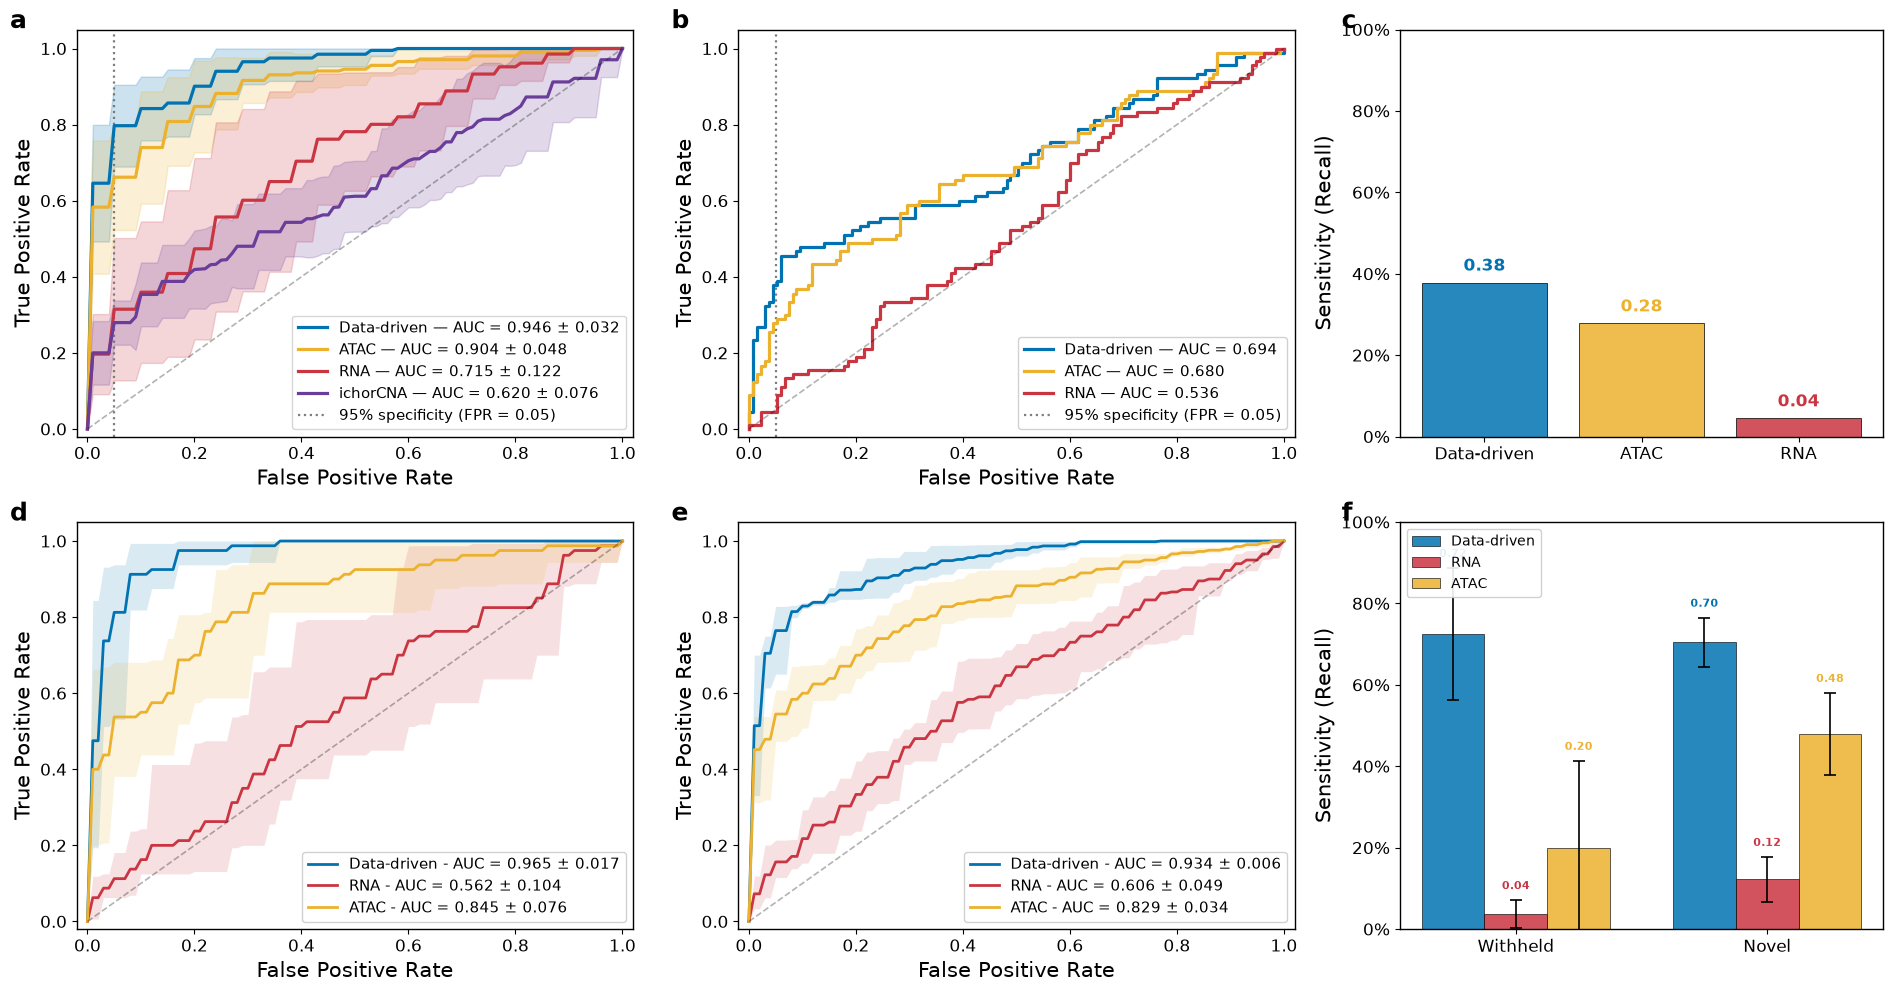

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10),
                         gridspec_kw={"width_ratios": [1.15, 1.15, 1]})
panel_a(axes[0, 0])
panel_b(axes[0, 1])
panel_c(axes[0, 2])
panel_roc_wg(axes[1, 0], "withheld")
panel_roc_wg(axes[1, 1], "novel")
panel_f(axes[1, 2])
for ax, letter in zip(axes.ravel(), "abcdef"):
    ax.text(-0.12, 1.05, letter, transform=ax.transAxes,
            fontsize=18, fontweight="bold", va="top")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")
plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/fig5.png", dpi=300, bbox_inches="tight")
fig.savefig("output/fig5.pdf", bbox_inches="tight")
plt.show()

## Check against the submitted manuscript values

In [6]:
print("Panel a (manuscript: Data-driven 0.946 ± 0.032, ATAC 0.904 ± 0.048, "
      "RNA 0.715 ± 0.122, ichorCNA 0.620 ± 0.076):")
for method in ["data_driven", "atac", "rna", "ichorcna"]:
    df = pred5a[(pred5a["method"] == method) & pred5a["fold"].notna()]
    aucs = []
    for _, g in df.groupby("fold"):
        g = expand(g).dropna(subset=["score"])
        fpr, tpr, _ = roc_curve(g["y_true"], g["score"])
        aucs.append(auc(fpr, tpr))
    print(f"  {METHOD_LABELS[method]:<12} {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

print("\nPanel b/c (manuscript 5b legend: Data-driven 0.694, ATAC 0.680, RNA 0.536; "
      "5c bars: 0.38 / 0.28 / 0.04):")
for method in ["dd", "atac", "rna"]:
    d = ext_rocs[method]
    print(f"  {METHOD_LABELS[method]:<12} AUC={d['auc']:.3f}  sens@95spec={d['sens_95_ext']:.2f}")

print("\nPanels d/e (manuscript: withheld DD 0.965 ± 0.017, RNA 0.562 ± 0.104, "
      "ATAC 0.845 ± 0.076; novel DD 0.934 ± 0.006, RNA 0.606 ± 0.049, ATAC 0.829 ± 0.034):")
print(wg_metrics[["method", "subset", "best_feature", "auc_mean", "auc_std",
                  "sens_95", "sens_95_std", "n_samples"]].to_string(index=False))

Panel a (manuscript: Data-driven 0.946 ± 0.032, ATAC 0.904 ± 0.048, RNA 0.715 ± 0.122, ichorCNA 0.620 ± 0.076):
  Data-driven  0.946 ± 0.032
  ATAC         0.904 ± 0.048
  RNA          0.715 ± 0.122
  ichorCNA     0.620 ± 0.076

Panel b/c (manuscript 5b legend: Data-driven 0.694, ATAC 0.680, RNA 0.536; 5c bars: 0.38 / 0.28 / 0.04):
  Data-driven  AUC=0.694  sens@95spec=0.38
  ATAC         AUC=0.680  sens@95spec=0.28
  RNA          AUC=0.536  sens@95spec=0.04

Panels d/e (manuscript: withheld DD 0.965 ± 0.017, RNA 0.562 ± 0.104, ATAC 0.845 ± 0.076; novel DD 0.934 ± 0.006, RNA 0.606 ± 0.049, ATAC 0.829 ± 0.034):
method   subset      best_feature  auc_mean  auc_std  sens_95  sens_95_std  n_samples
    dd withheld      griffin_diff  0.965476 0.016517 0.725000     0.162980         58
    dd    novel      griffin_diff  0.934370 0.005905 0.704839     0.060511        124
   rna withheld              rcov  0.562500 0.103548 0.037500     0.034233         58
   rna    novel              rcov  0.6